In [167]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import matplotlib.ticker as mtick
import numpy as np
from scipy.stats import chisquare
from scipy.stats import ks_2samp
import re

In [154]:
data = pd.read_csv('../data/idealista_barcelona_sale_urls_geocoded.csv')
data_found = data[(data['geocode_match_type']=='primary') & (~data['price_search'].isna())] # Data with exact geolocation and price available
data_found.shape

(1054, 33)

In [155]:
data_found.columns

Index(['propertyCode', 'url', 'address_search', 'price_search',
       'details_search', 'description_search', 'source_page', 'scraped_at',
       'seed_url', 'seed_label', 'price_eur', 'address_source_column',
       'address_source_text', 'address_candidate', 'has_address_candidate',
       'has_street_word', 'has_street_number', 'geocode_eligible_primary',
       'geocode_query_primary', 'geocode_eligible_fallback',
       'geocode_query_fallback', 'geocode_eligible', 'geocode_query', 'lat',
       'lon', 'display_name', 'importance', 'osm_type', 'osm_id',
       'geocode_status', 'geocoded_at', 'geocode_match_type', 'geocode_found'],
      dtype='str')

### 1. Spatial Distribution

In [156]:

m = folium.Map(location=[41.3851, 2.1734], zoom_start=13, tiles='CartoDB positron')

median_price = data_found['price_eur'].median()

for idx, row in data_found.iterrows():

    color="#4C934C"
    
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=3,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.6,
        popup=f"Price: {row['price_eur']:.0f}€"
    ).add_to(m)

# 4. Save and view
m.save('spatial_distribution.html')
print("Map saved as 'spatial_distribution.html'. Open it in your browser!")

Map saved as 'spatial_distribution.html'. Open it in your browser!


### 2. Price Distribution

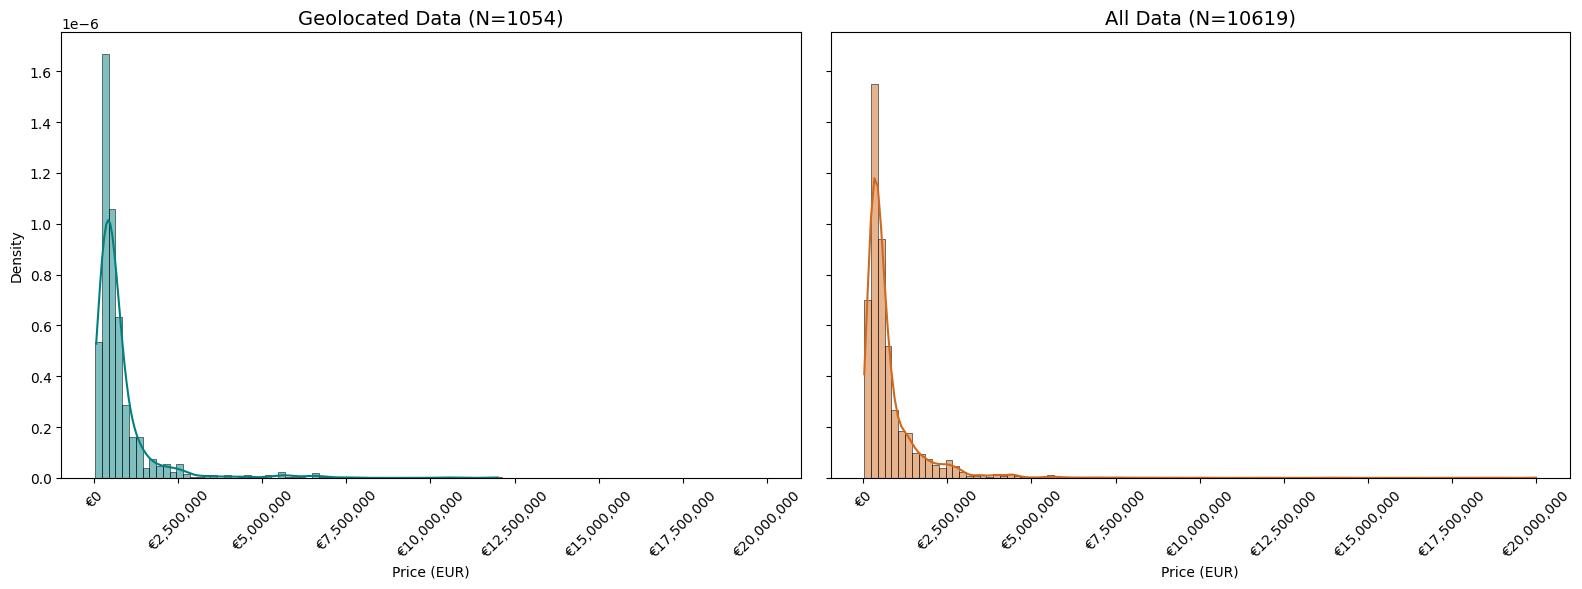

In [157]:
min_val, max_val = data['price_eur'].min(), data['price_eur'].max()
num_bins = 100
shared_bins = np.linspace(min_val, max_val, num_bins)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

sns.histplot(data=data_found, x='price_eur', bins=shared_bins, kde=True, 
             stat='density', ax=axes[0], color="teal")
axes[0].set_title(f'Geolocated Data (N={data_found.shape[0]})', fontsize=14)

sns.histplot(data=data, x='price_eur', bins=shared_bins, kde=True, 
             stat='density', ax=axes[1], color="#D0681D")
axes[1].set_title(f'All Data (N={data.shape[0]})', fontsize=14)

for ax in axes:
    ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('€{x:,.0f}'))
    plt.setp(ax.get_xticklabels(), rotation=45)
    ax.set_xlabel('Price (EUR)')

plt.tight_layout()
plt.show()

In [158]:
pd.options.display.float_format = '{:,.2f}'.format

print('Geolocated Sample:')
display(data_found[['price_eur']].describe())
        
print('Full Sample:')
display(data[['price_eur']].describe())

Geolocated Sample:


,price_eur
count,"1,054.00"
mean,"755,614.40"
std,"1,010,019.49"
min,"62,500.00"
25%,"325,000.00"
50%,"481,000.00"
75%,"760,000.00"
max,"12,000,000.00"


Full Sample:


,price_eur
count,"10,596.00"
mean,"780,907.65"
std,"1,053,723.36"
min,"28,000.00"
25%,"298,000.00"
50%,"475,000.00"
75%,"835,000.00"
max,"20,000,000.00"


In [159]:
ks_stat, p_val_ks = ks_2samp(data_found['price_eur'].dropna(), data['price_eur'].dropna())

print(f"Kolmogorov-Smirnov p-value: {p_val_ks:.4f}")

Kolmogorov-Smirnov p-value: 0.0307


### 3. District Distribution

In [160]:
print('Geolocated Sample:')
nan_found = (data_found["seed_label"].isna()).value_counts().loc[True]

print(f'    NaN for District Data: {nan_found} ({round(nan_found/data_found.shape[0]*100,2)}%)')
district_found = data_found.groupby(['seed_label']).agg({
    'propertyCode': 'count', 
    'price_eur': ['mean', 'median', 'std', 'min', 'max']
})
district_found.columns = ['count', 'mean', 'median', 'std', 'min', 'max']
district_found['share'] = district_found['count'] / (data_found.shape[0]-(data_found["seed_label"].isna()).value_counts().loc[True]) * 100
district_found = district_found[['count', 'share', 'mean', 'median', 'std', 'min', 'max']]
display(district_found)

print('Full Sample:')
nan_full = (data["seed_label"].isna()).value_counts().loc[True]
print(f'    NaN for District Data: {nan_full} ({round(nan_full/data.shape[0]*100, 2)}%)')
district_full = data.groupby(['seed_label']).agg({
    'propertyCode': 'count', 
    'price_eur': ['mean', 'median', 'std', 'min', 'max']
})
district_full.columns = ['count', 'mean', 'median', 'std', 'min', 'max']
district_full['share'] = district_full['count'] / (data.shape[0]-(data["seed_label"].isna()).value_counts().loc[True]) * 100
district_full = district_full[['count', 'share', 'mean', 'median', 'std', 'min', 'max']]
display(district_full)

Geolocated Sample:
    NaN for District Data: 137 (13.0%)


,count,share,mean,median,std,min,max
seed_label,,,,,,,
ciutat-vella,160,17.45,"495,918.12","360,500.00","475,674.32","94,000.00","4,495,000.00"
eixample,89,9.71,"923,415.73","650,000.00","765,422.06","215,000.00","5,200,000.00"
gracia,75,8.18,"795,285.11","450,000.00","1,481,217.22","110,000.00","12,000,000.00"
horta-guinardo,113,12.32,"383,069.34","348,400.00","268,211.84","80,000.00","2,380,000.00"
les-corts,32,3.49,"963,328.12","617,000.00","1,463,016.77","206,000.00","7,000,000.00"
nou-barris,79,8.62,"308,794.11","290,000.00","174,627.03","62,500.00","775,000.00"
sant-andreu,51,5.56,"438,016.96","395,000.00","216,327.27","79,000.00","859,000.00"
sant-marti,138,15.05,"1,237,364.96","573,687.00","1,533,521.10","80,000.00","7,600,000.00"
sants-montjuic,103,11.23,"422,068.92","396,000.00","159,256.51","125,000.00","1,100,000.00"


Full Sample:
    NaN for District Data: 1578 (14.86%)


,count,share,mean,median,std,min,max
seed_label,,,,,,,
ciutat-vella,1504,16.64,"468,025.27","366,000.00","369,670.52","85,000.00","4,495,000.00"
eixample,1254,13.87,"938,578.50","675,000.00","837,507.34","135,000.00","13,800,000.00"
gracia,712,7.88,"647,530.99","490,000.00","818,265.90","106,000.00","12,000,000.00"
horta-guinardo,807,8.93,"384,619.14","315,000.00","268,991.67","50,000.00","2,900,000.00"
les-corts,394,4.36,"1,875,065.61","835,000.00","2,814,330.11","34,480.00","20,000,000.00"
nou-barris,736,8.14,"247,032.58","200,000.00","181,504.01","28,000.00","2,750,000.00"
sant-andreu,494,5.46,"358,361.90","309,250.00","332,945.36","28,000.00","3,700,000.00"
sant-marti,1150,12.72,"680,145.46","400,000.00","840,369.72","70,000.00","7,600,000.00"
sants-montjuic,1082,11.97,"369,127.78","345,000.00","163,418.80","58,590.00","2,100,000.00"


In [161]:
# 1. Get the counts for each district in both samples
found_counts = data_found['seed_label'].dropna().value_counts().sort_index()
full_proportions = data['seed_label'].dropna().value_counts(normalize=True).sort_index()

# 2. Calculate expected counts for the sample based on full population proportions
expected_counts = full_proportions * found_counts.sum()

# 3. Run the test
chi_stat, p_val = chisquare(f_obs=found_counts, f_exp=expected_counts)

print(f"Chi-Squared p-value: {p_val:.4f}")

Chi-Squared p-value: 0.0002


In the final Residual-on-Residual regression, we must use weighted OLS with the Inverse Probability Weighting (IPW): $$Weight_{district} = \frac{\% \text{ in Full Sample}}{\% \text{ in Geolocated Sample}}$$

### 4. Bedroom Distribution

Geolocated Sample:
     NaN values: 36 (3.42%)


count   1,018.00
mean        2.74
std         1.12
min         1.00
25%         2.00
50%         3.00
75%         3.00
max         7.00
Name: bedrooms, dtype: float64

Full Sample:
     NaN values: 202 (1.9%)


count   10,417.00
mean         2.96
std          1.33
min          1.00
25%          2.00
50%          3.00
75%          4.00
max         27.00
Name: bedrooms, dtype: float64

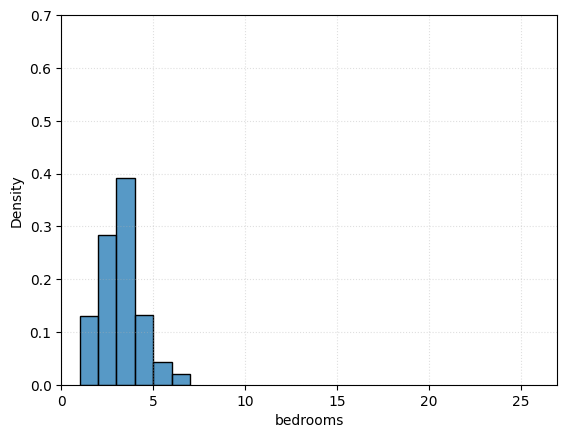

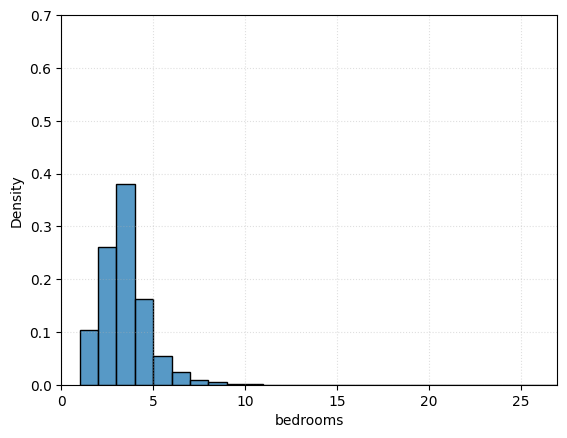

Kolmogorov-Smirnov p-value: 0.0014


In [183]:
pattern = r'(\d+)\s*bed'

data_found['bedrooms'] = data_found['details_search'].str.extract(pattern, flags=re.IGNORECASE)
data_found['bedrooms'] = pd.to_numeric(data_found['bedrooms'])

data['bedrooms'] = data['details_search'].str.extract(pattern, flags=re.IGNORECASE)
data['bedrooms'] = pd.to_numeric(data['bedrooms'])

ks_stat, p_val_ks = ks_2samp(data_found['bedrooms'].dropna(), data['bedrooms'].dropna())

print('Geolocated Sample:')
print(f'     NaN values: {sum(data_found["bedrooms"].isna().astype(int))} ({round(sum(data_found["bedrooms"].isna().astype(int)) / data_found.shape[0] * 100, 2)}%)')
display(data_found['bedrooms'].describe())

print('Full Sample:')
print(f'     NaN values: {sum(data["bedrooms"].isna().astype(int))} ({round(sum(data["bedrooms"].isna().astype(int)) / data.shape[0] * 100, 2)}%)')
display(data['bedrooms'].describe())

sns.histplot(data=data_found, x='bedrooms', stat='density', bins=6)
plt.xlim([0,27])
plt.ylim([0,0.7])
plt.grid(alpha=0.4, linestyle=':')
plt.show()

sns.histplot(data=data, x='bedrooms', stat='density', bins=26)
plt.xlim([0,27])
plt.ylim([0,0.7])
plt.grid(alpha=0.4, linestyle=':')
plt.show()

print(f"Kolmogorov-Smirnov p-value: {p_val_ks:.4f}")

### 5. Square Meters Distribution

Geolocated Sample:
     NaN values: 0 (0.0%)


count   1,054.00
mean      108.03
std        79.69
min        18.00
25%        68.00
50%        88.00
75%       124.00
max       895.00
Name: sq_mts, dtype: float64

Full Sample:
     NaN values: 23 (0.22%)


count   10,596.00
mean       119.34
std         96.58
min          0.00
25%         67.00
50%         90.00
75%        133.00
max        981.00
Name: sq_mts, dtype: float64

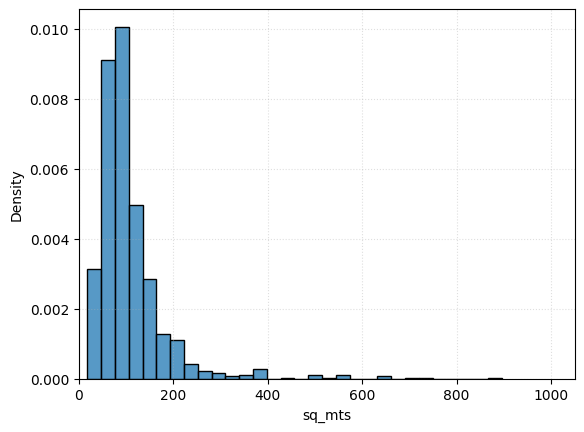

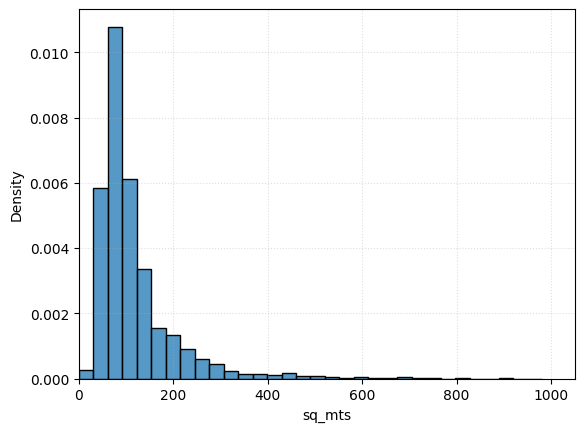

Kolmogorov-Smirnov p-value: 0.0017


In [189]:
pattern = r'(\d+)\s*m²'

data_found['sq_mts'] = data_found['details_search'].str.extract(pattern, flags=re.IGNORECASE)
data_found['sq_mts'] = pd.to_numeric(data_found['sq_mts'])

data['sq_mts'] = data['details_search'].str.extract(pattern, flags=re.IGNORECASE)
data['sq_mts'] = pd.to_numeric(data['sq_mts'])

ks_stat, p_val_ks = ks_2samp(data_found['sq_mts'].dropna(), data['sq_mts'].dropna())

print('Geolocated Sample:')
print(f'     NaN values: {sum(data_found["sq_mts"].isna().astype(int))} ({round(sum(data_found["sq_mts"].isna().astype(int)) / data_found.shape[0] * 100, 2)}%)')
display(data_found['sq_mts'].describe())

print('Full Sample:')
print(f'     NaN values: {sum(data["sq_mts"].isna().astype(int))} ({round(sum(data["sq_mts"].isna().astype(int)) / data.shape[0] * 100, 2)}%)')
display(data['sq_mts'].describe())

sns.histplot(data=data_found, x='sq_mts', stat='density', bins=30)
plt.grid(alpha=0.4, linestyle=':')
plt.xlim([0,1050])
plt.show()

sns.histplot(data=data, x='sq_mts', stat='density', bins=32)
plt.grid(alpha=0.4, linestyle=':')
plt.xlim([0,1050])
plt.show()

print(f"Kolmogorov-Smirnov p-value: {p_val_ks:.4f}")

In [195]:
data_found.columns

Index(['propertyCode', 'url', 'address_search', 'price_search',
       'details_search', 'description_search', 'source_page', 'scraped_at',
       'seed_url', 'seed_label', 'price_eur', 'address_source_column',
       'address_source_text', 'address_candidate', 'has_address_candidate',
       'has_street_word', 'has_street_number', 'geocode_eligible_primary',
       'geocode_query_primary', 'geocode_eligible_fallback',
       'geocode_query_fallback', 'geocode_eligible', 'geocode_query', 'lat',
       'lon', 'display_name', 'importance', 'osm_type', 'osm_id',
       'geocode_status', 'geocoded_at', 'geocode_match_type', 'geocode_found',
       'bedrooms', 'sq_mts'],
      dtype='str')

### Summary

In [199]:
import numpy as np
import pandas as pd

# Define your numeric columns to check
cols_to_check = ['price_eur', 'sq_mts', 'bedrooms']

results = []

for col in cols_to_check:
    # 1. Get means
    mean_full = data[col].mean()
    mean_geo = data_found[col].mean()
    
    # 2. Get variances
    var_full = data[col].var()
    var_geo = data_found[col].var()
    
    # 3. Calculate pooled standard deviation
    pooled_sd = np.sqrt((var_full + var_geo) / 2)
    
    # 4. Calculate SMD (Absolute difference divided by pooled SD)
    smd = np.abs(mean_full - mean_geo) / pooled_sd
    
    results.append({
        'Variable': col,
        'Full Sample Mean': mean_full,
        'Geolocated Mean': mean_geo,
        'SMD': smd
    })

balance_table = pd.DataFrame(results)
pd.options.display.float_format = '{:,.3f}'.format
display(balance_table)

,Variable,Full Sample Mean,Geolocated Mean,SMD
0,price_eur,"780,907.648","755,614.400",0.025
1,sq_mts,119.338,108.028,0.128
2,bedrooms,2.959,2.737,0.181
